In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
df = pd.read_csv("/content/Unemployment in India.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Rows: 768
Columns: 7

Column names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Data types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [6]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [7]:
print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

display(missing_df)

,Missing Values,Percentage
Region,28,3.645833
Date,28,3.645833
Frequency,28,3.645833
Estimated Unemployment Rate (%),28,3.645833
Estimated Employed,28,3.645833
Estimated Labour Participation Rate (%),28,3.645833
Area,28,3.645833


In [9]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 27
Duplicates after: 0


In [10]:
df["Date"] = df["Date"].astype(str).str.strip()

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

print(df["Date"].head())

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


In [11]:
print("Invalid dates:", df["Date"].isna().sum())

Invalid dates: 1


In [12]:
df = df.dropna(subset=["Date"])

In [13]:
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [14]:
print(df[numeric_columns].dtypes)

Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
dtype: object


In [15]:
print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [16]:
df = df.dropna()

print("Final shape:", df.shape)

Final shape: (740, 7)


In [17]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,Jun
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,Jul
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,Aug
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,Sep


In [18]:
print(df.describe())

                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  \
count        7.400000e+02                               740.000000   
mean         7.204460e+06                                42.630122   
min          4.942000e+04                                13.330000   
25%          1.190404e+06                                38.06

In [19]:
print(
    df["Estimated Unemployment Rate (%)"].describe()
)

count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Estimated Unemployment Rate (%), dtype: float64


In [20]:
average_unemployment = df["Estimated Unemployment Rate (%)"].mean()
maximum_unemployment = df["Estimated Unemployment Rate (%)"].max()
minimum_unemployment = df["Estimated Unemployment Rate (%)"].min()

print("Average unemployment:", round(average_unemployment, 2), "%")
print("Maximum unemployment:", round(maximum_unemployment, 2), "%")
print("Minimum unemployment:", round(minimum_unemployment, 2), "%")

Average unemployment: 11.79 %
Maximum unemployment: 76.74 %
Minimum unemployment: 0.0 %


In [21]:
highest = df.loc[
    df["Estimated Unemployment Rate (%)"].idxmax()
]

print(highest)

Region                                              Puducherry
Date                                       2020-04-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                          76.74
Estimated Employed                                     68122.0
Estimated Labour Participation Rate (%)                  35.54
Area                                                     Urban
Year                                                      2020
Month                                                        4
Month_Name                                                 Apr
Name: 627, dtype: object


In [22]:
lowest = df.loc[
    df["Estimated Unemployment Rate (%)"].idxmin()
]

print(lowest)

Region                                                   Assam
Date                                       2020-06-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                            0.0
Estimated Employed                                   7544937.0
Estimated Labour Participation Rate (%)                  34.38
Area                                                     Rural
Year                                                      2020
Month                                                        6
Month_Name                                                 Jun
Name: 25, dtype: object


In [23]:
lowest = df.loc[
    df["Estimated Unemployment Rate (%)"].idxmin()
]

print(lowest)

Region                                                   Assam
Date                                       2020-06-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                            0.0
Estimated Employed                                   7544937.0
Estimated Labour Participation Rate (%)                  34.38
Area                                                     Rural
Year                                                      2020
Month                                                        6
Month_Name                                                 Jun
Name: 25, dtype: object


In [24]:
monthly_unemployment = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

monthly_unemployment.head()

,Date,Estimated Unemployment Rate (%)
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731


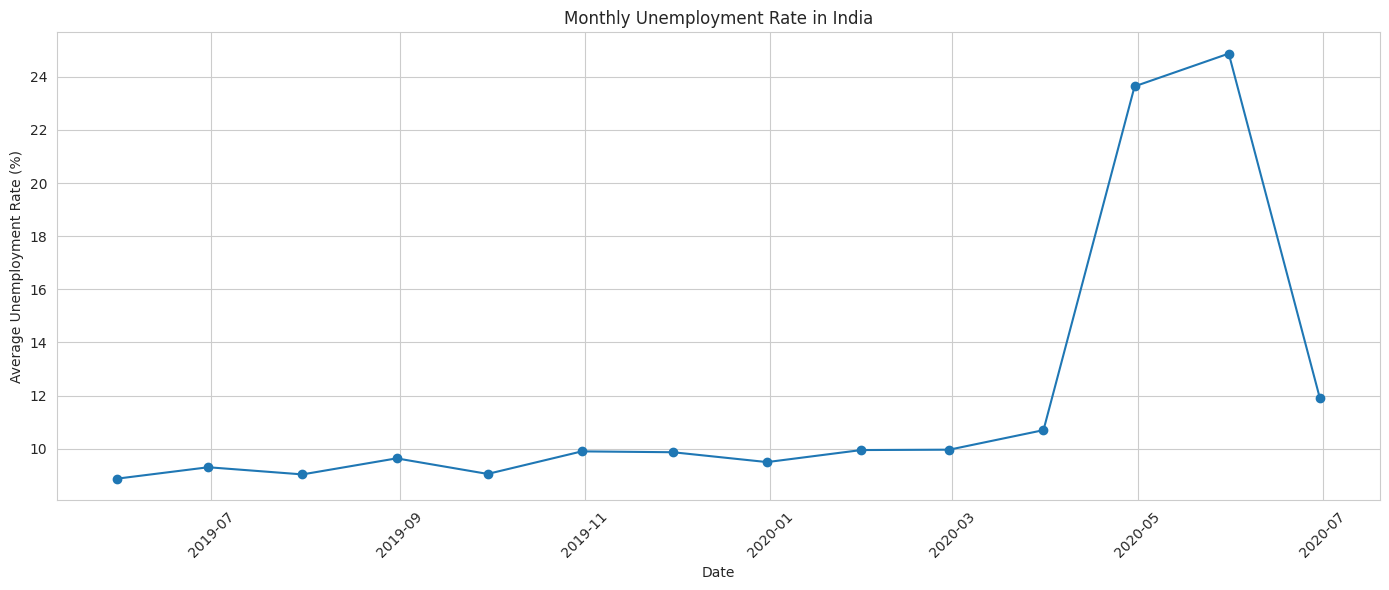

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_unemployment["Date"],
    monthly_unemployment["Estimated Unemployment Rate (%)"],
    marker="o"
)

plt.title("Monthly Unemployment Rate in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "01_monthly_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
covid_comparison = (
    df.groupby("Year")["Estimated Unemployment Rate (%)"]
    .mean()
)

print(covid_comparison)

Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


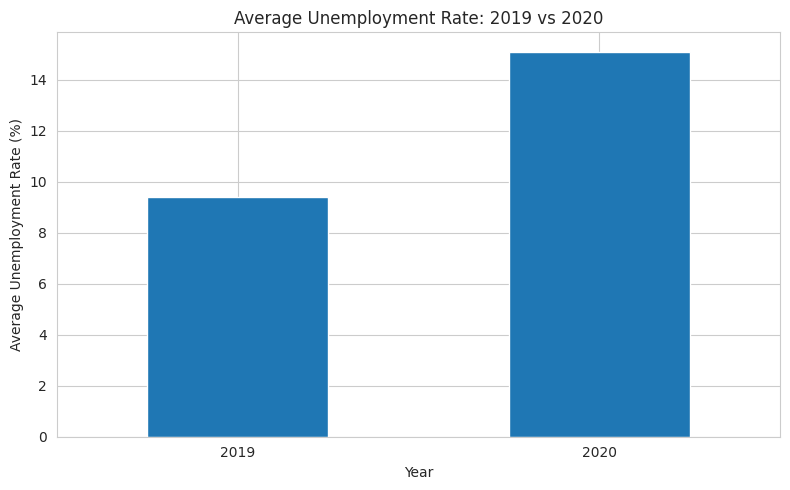

In [27]:
plt.figure(figsize=(8, 5))

covid_comparison.plot(
    kind="bar"
)

plt.title("Average Unemployment Rate: 2019 vs 2020")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "02_covid_impact.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
if 2019 in covid_comparison.index and 2020 in covid_comparison.index:

    change = (
        covid_comparison.loc[2020]
        - covid_comparison.loc[2019]
    )

    print(
        f"Change from 2019 to 2020: {change:.2f} percentage points"
    )

Change from 2019 to 2020: 5.70 percentage points


In [29]:
monthly_pattern = (
    df.groupby("Month")[
        "Estimated Unemployment Rate (%)"
    ].mean()
)

print(monthly_pattern)

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Estimated Unemployment Rate (%), dtype: float64


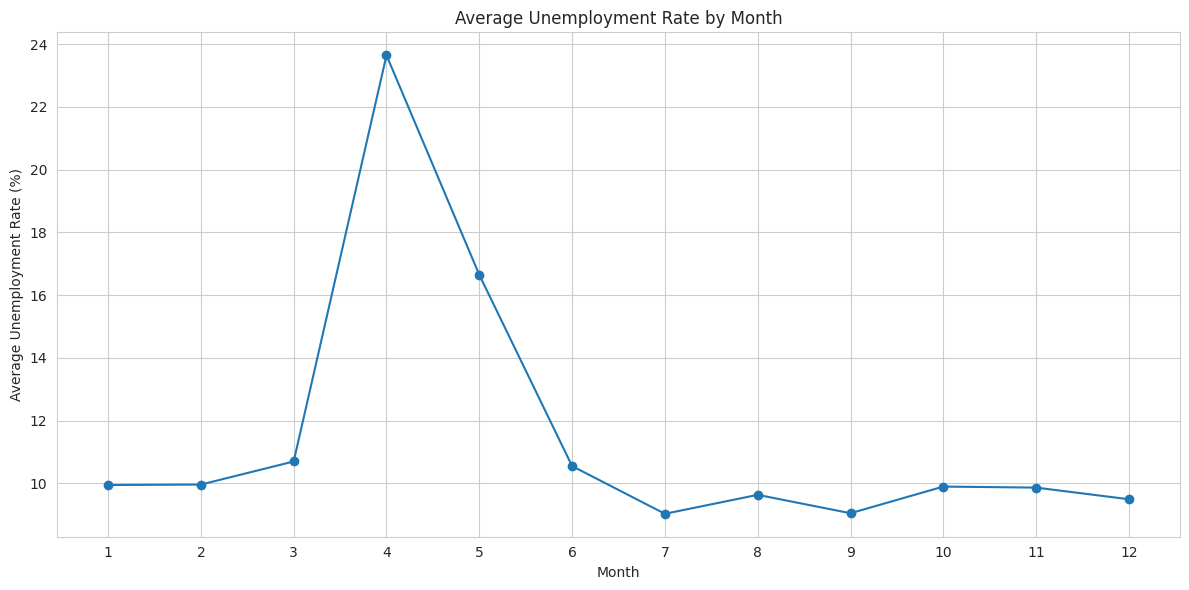

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker="o"
)

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(range(1, 13))

plt.tight_layout()

plt.savefig(
    "04_monthly_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
region_unemployment = (
    df.groupby("Region")[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()
    .sort_values(ascending=False)
)

print(region_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


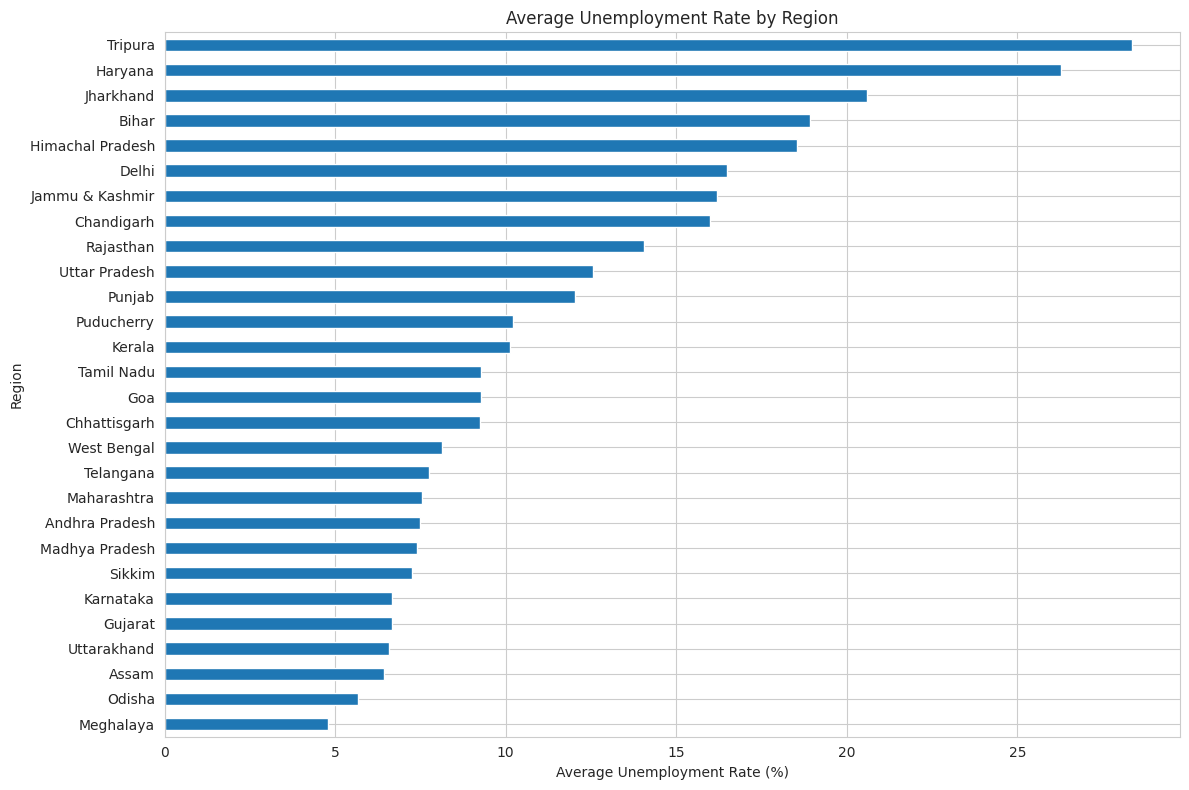

In [32]:
plt.figure(figsize=(12, 8))

region_unemployment.sort_values().plot(
    kind="barh"
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    "03_region_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
top_10_regions = region_unemployment.head(10)

print(top_10_regions)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


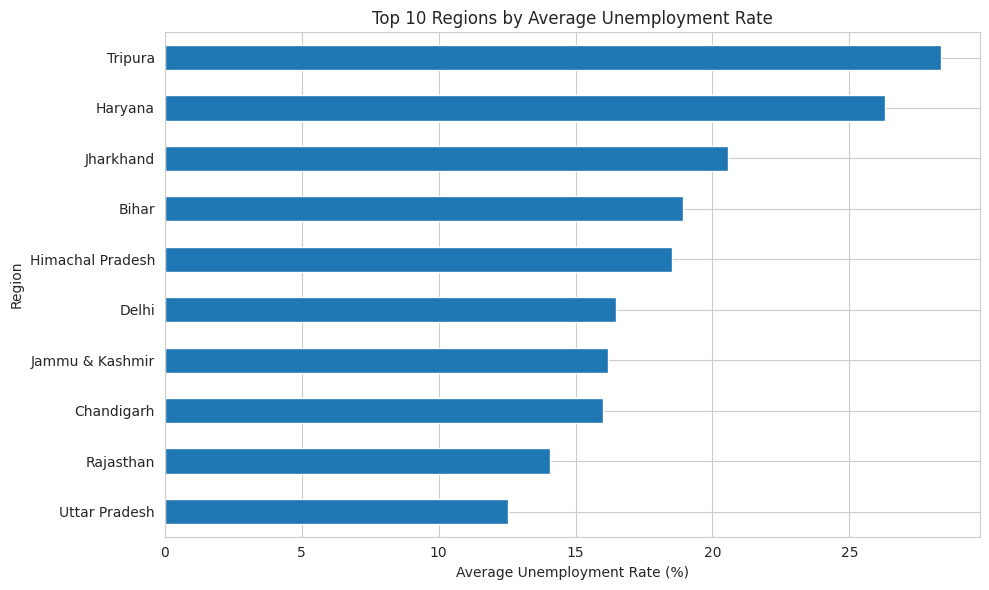

In [34]:
plt.figure(figsize=(10, 6))

top_10_regions.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")

plt.tight_layout()

plt.show()

In [35]:
area_unemployment = (
    df.groupby("Area")[
        "Estimated Unemployment Rate (%)"
    ].mean()
)

print(area_unemployment)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


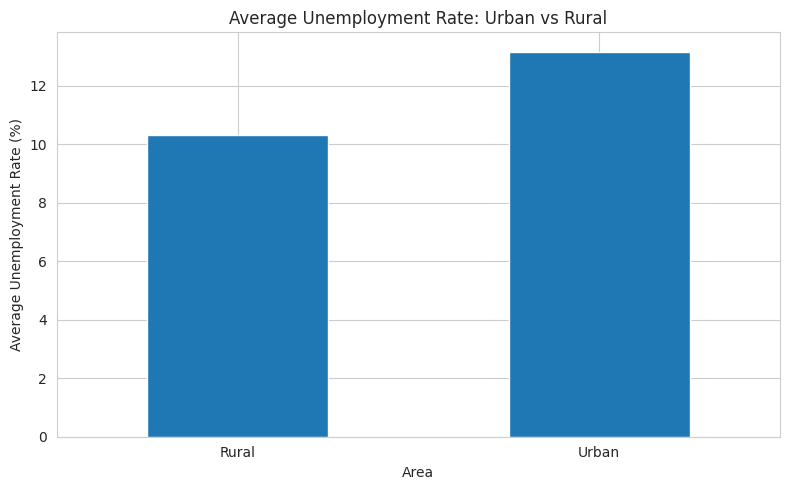

In [36]:
plt.figure(figsize=(8, 5))

area_unemployment.plot(
    kind="bar"
)

plt.title("Average Unemployment Rate: Urban vs Rural")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "05_urban_rural.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

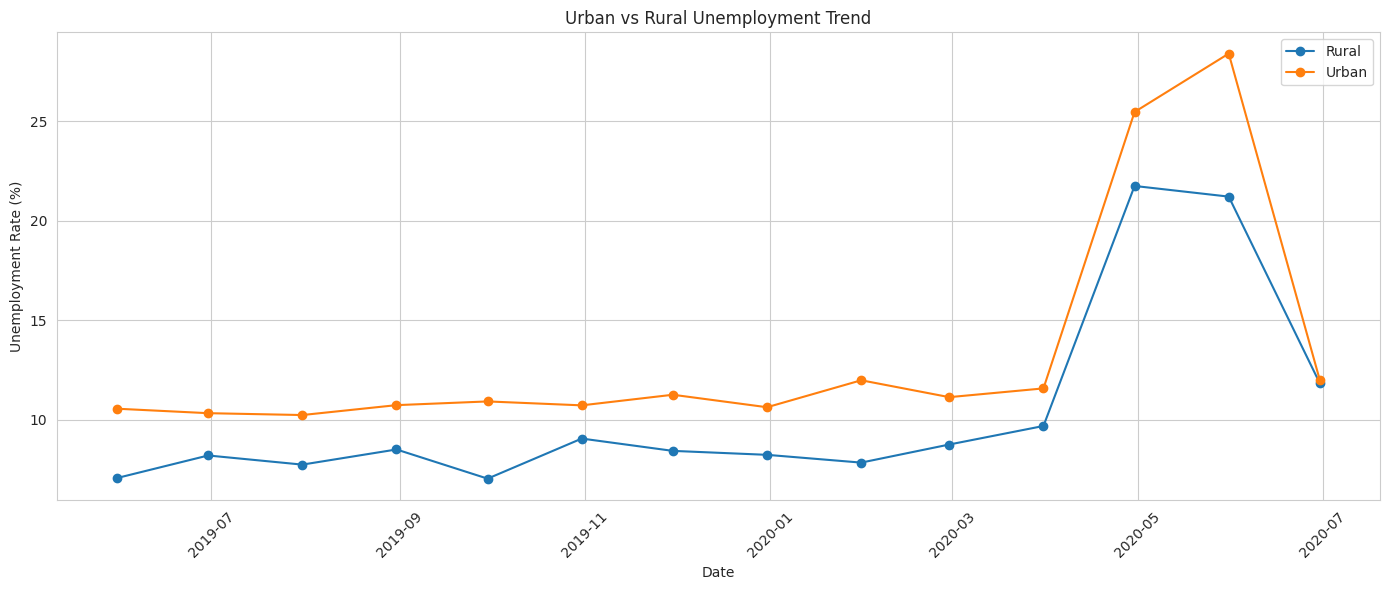

In [37]:
urban_rural_trend = (
    df.groupby(["Date", "Area"])[
        "Estimated Unemployment Rate (%)"
    ]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

for area in urban_rural_trend["Area"].unique():

    temp = urban_rural_trend[
        urban_rural_trend["Area"] == area
    ]

    plt.plot(
        temp["Date"],
        temp["Estimated Unemployment Rate (%)"],
        marker="o",
        label=area
    )

plt.title("Urban vs Rural Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

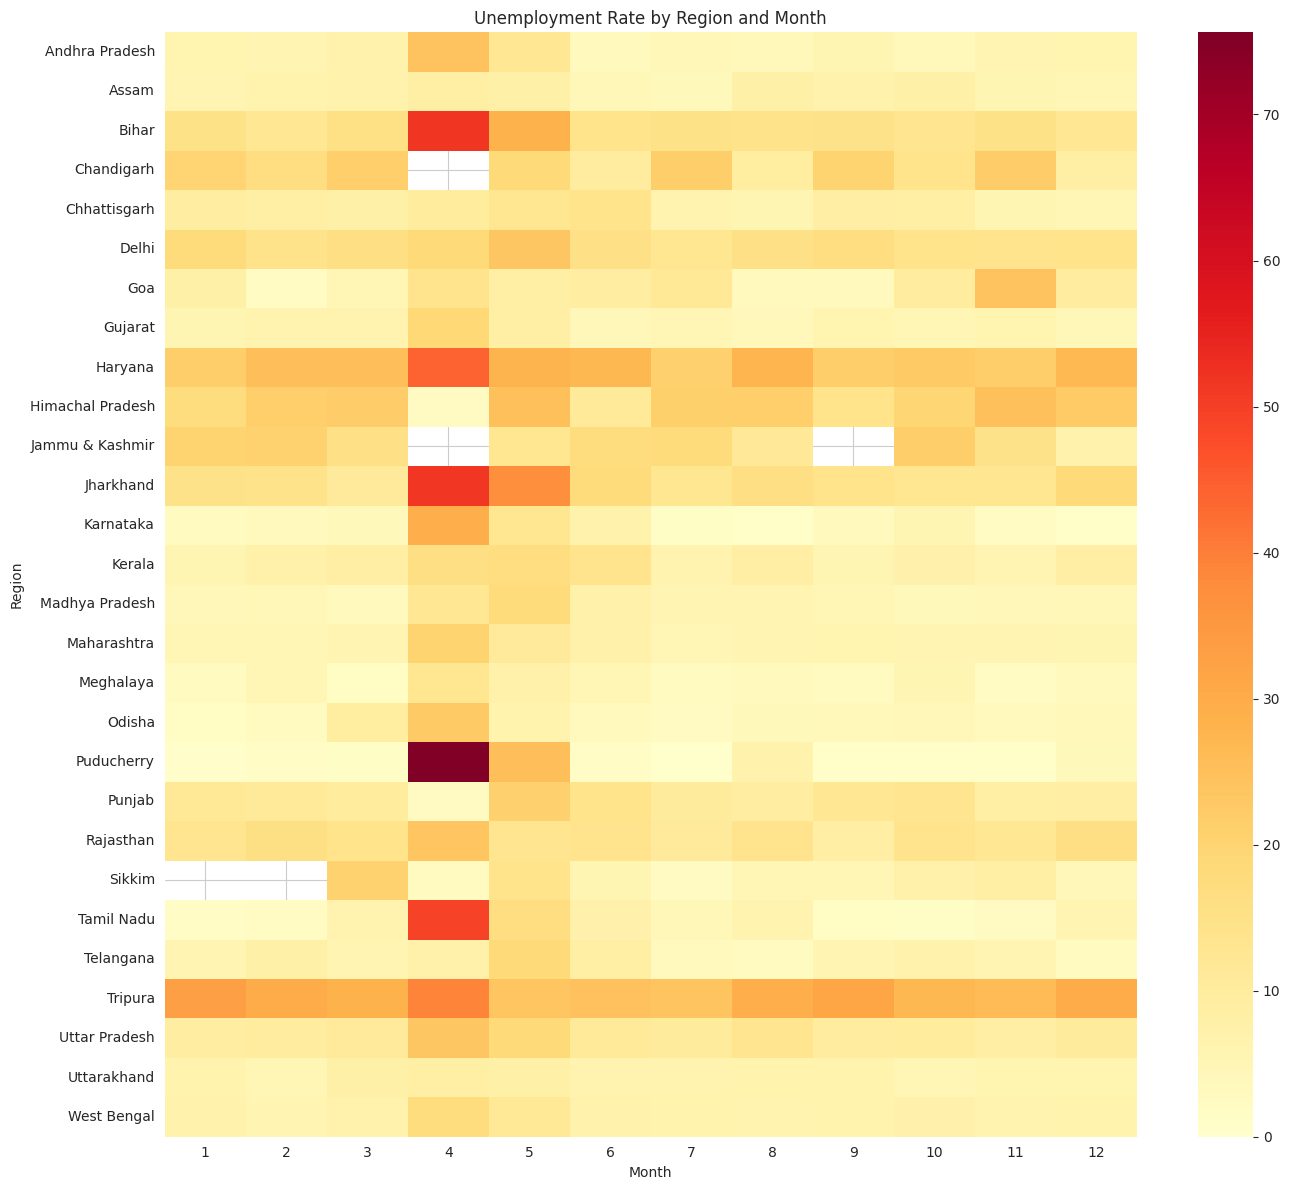

In [38]:
heatmap_data = df.pivot_table(
    index="Region",
    columns="Month",
    values="Estimated Unemployment Rate (%)",
    aggfunc="mean"
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap="YlOrRd"
)

plt.title("Unemployment Rate by Region and Month")
plt.xlabel("Month")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    "06_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
highest_region = region_unemployment.idxmax()
highest_region_value = region_unemployment.max()

lowest_region = region_unemployment.idxmin()
lowest_region_value = region_unemployment.min()

highest_month = monthly_pattern.idxmax()
highest_month_value = monthly_pattern.max()

lowest_month = monthly_pattern.idxmin()
lowest_month_value = monthly_pattern.min()

print("===== TASK 2 KEY INSIGHTS =====")

print(
    f"1. Overall average unemployment rate: "
    f"{average_unemployment:.2f}%"
)

print(
    f"2. Highest regional average: "
    f"{highest_region} ({highest_region_value:.2f}%)"
)

print(
    f"3. Lowest regional average: "
    f"{lowest_region} ({lowest_region_value:.2f}%)"
)

print(
    f"4. Month with highest average unemployment: "
    f"{highest_month} ({highest_month_value:.2f}%)"
)

print(
    f"5. Month with lowest average unemployment: "
    f"{lowest_month} ({lowest_month_value:.2f}%)"
)

print(
    f"6. Urban/Rural averages:\n{area_unemployment}"
)

===== TASK 2 KEY INSIGHTS =====
1. Overall average unemployment rate: 11.79%
2. Highest regional average: Tripura (28.35%)
3. Lowest regional average: Meghalaya (4.80%)
4. Month with highest average unemployment: 4 (23.64%)
5. Month with lowest average unemployment: 7 (9.03%)
6. Urban/Rural averages:
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


In [40]:
print("========== TASK 2 FINAL RESULTS ==========")

print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

print(f"\nAverage unemployment rate: "
      f"{average_unemployment:.2f}%")

print(f"Highest unemployment rate: "
      f"{maximum_unemployment:.2f}%")

print(f"Lowest unemployment rate: "
      f"{minimum_unemployment:.2f}%")

print(f"\nHighest-average-unemployment region: "
      f"{highest_region} ({highest_region_value:.2f}%)")

print(f"Lowest-average-unemployment region: "
      f"{lowest_region} ({lowest_region_value:.2f}%)")

print(f"\nMonth with highest average unemployment: "
      f"{highest_month} ({highest_month_value:.2f}%)")

print(f"Month with lowest average unemployment: "
      f"{lowest_month} ({lowest_month_value:.2f}%)")

print("\nUrban/Rural unemployment:")
print(area_unemployment)

print("\n==========================================")

========== TASK 2 FINAL RESULTS ==========
Dataset rows: 740
Dataset columns: 10

Average unemployment rate: 11.79%
Highest unemployment rate: 76.74%
Lowest unemployment rate: 0.00%

Highest-average-unemployment region: Tripura (28.35%)
Lowest-average-unemployment region: Meghalaya (4.80%)

Month with highest average unemployment: 4 (23.64%)
Month with lowest average unemployment: 7 (9.03%)

Urban/Rural unemployment:
Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64



In [41]:
import os
import zipfile

graph_files = [
    "01_monthly_trend.png",
    "02_covid_impact.png",
    "03_region_analysis.png",
    "04_monthly_pattern.png",
    "05_urban_rural.png",
    "06_heatmap.png"
]

with zipfile.ZipFile(
    "Task2_Graphs.zip",
    "w"
) as zipf:

    for file in graph_files:
        if os.path.exists(file):
            zipf.write(file)

print("Task 2 graphs ZIP created.")

Task 2 graphs ZIP created.


In [42]:
from google.colab import files

files.download("Task2_Graphs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>